
<div align="center">

# Devoir 3
### PHY-7009 – Analyse des signaux (A26)

**Cassandra Mantha**, 537 014 158

**Elias Ouellet-Oviedo**, 537 003 135  

<br><br>

Présenté à **Antoine Godin**

</div>

In [1]:
from __future__ import annotations
from pathlib import Path
import re
import numpy as np
import sys
import io
from IPython.display import Image, display
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib
matplotlib.use("Agg") 

from ics_batch import discover_dataset, analyze_category, summary_table
from ics_plots import (plot_case_overview, plot_density_effect, plot_imagesize_effect,
                        plot_noise_effect, plot_pixelsize_effect, plot_schema,)


from mpl_toolkits.mplot3d import Axes3D  # noqa: F401 (necessaire pour projection='3d')
from ics_core import crop_center, _gaussian2d

plt.rcParams.update({"figure.dpi": 110, "font.size": 10, "axes.grid": False, "grid.alpha": 0.3})
plt.style.use('https://raw.githubusercontent.com/dccote/Enseignement/master/SRC/dccote-basic.mplstyle')

La fonction d'autocorrélation spatiale normalisée $r(\xi, \eta)$ mesure la corrélation des fluctuations entre deux pixels séparés par un décalage spatial (lag) de $\xi$ pixels en $x$ et $\eta$ pixels en $y$ : 
$$r(\xi, \eta) = \frac{\langle \delta i(x, y) \cdot \delta i(x+\xi, y+\eta) \rangle}{\langle i \rangle^2}.$$

Pour accélérer le calcul sur des images entières, on utilise le théorème de Wiener-Khinchin, la transformée de Fourier rapide 2D (FFT) : 
$$r(\xi, \eta) = \frac{\mathcal{F}^{-1}\left( |\mathcal{F}(I(x,y))|^2 \right)}{\langle i \rangle^2} - 1.$$

Pour un système de particules indépendantes, le carré moyen des fluctuations divisé par le carré de l'intensité moyenne est égal à l'inverse du nombre moyen de particules $\langle N \rangle$ présentes dans la tache focale du laser (Beam Area) : 
$$g(0,0) = \frac{1}{\langle N \rangle}.$$

Ainsi, plus la densité d'émetteurs est élevée, plus l'amplitude relative des fluctuations $g(0,0)$ est faible.

Le bruit de photon ou bruit électronique du détecteur est un bruit blanc indépendant d'un pixel à l'autre. Il ne se correle qu'avec lui-même au même pixel, ajoutant une pointe artificielle uniquement au lag central $(0,0)$. En revanche, le signal fluorescent issu de la tache focale (PSF) s'étale sur plusieurs pixels adjacents. En ajustant la fonction par un modèle gaussien 2D en excluant le point central $(0,0)$, on extrapole l'amplitude réelle du signal $g(0,0)$ sans le biais du bruit.

La fonction d'autocorrélation spatiale d'une PSF gaussienne s'écrit : 
$$G(\xi, \eta) = g(0,0) \exp\left( -\frac{\xi^2 + \eta^2}{\omega_{xy}^2} \right) + g_\infty,$$
où $\omega_{xy}$ représente le waist (rayon à $1/e^2$) de la PSF et $g_\infty$ est un décalage asymptotique. Si la taille de pixel est trop grande par rapport à $\omega_{xy}$, le sous-échantillonnage viole le critère de Shannon-Nyquist, déformant le profil gaussien et empêchant l'ajustement correct de la courbe.

In [2]:
BASE_DIR = Path(r"C:\Users\User\OneDrive\Bureau\Université\Maitrise\cours\Analyse des signaux\Projets\Projet 3\ICS_analysis\simulations")          # dossier racine fourni par l'enseignant
OUTPUT_DIR = Path("resultats_ICS")      # où ecrire les figures / tableaux

PIXEL_SIZE_UM_DEFAULT = 0.05            # taille de pixel nominale (µm/pixel)
PSF_OMEGA_UM = 0.2                      # rayon 1/e^2 nominal de la PSF (µm)
DEFAULT_DENSITY_PER_BA = 10             # densite nominale par defaut (part./beam area)


NOMINAL_DENSITIES: dict[str, float] = {}

# Taille de pixel (µm) 
def pixel_size_from_case_name(name: str, fallback: float = PIXEL_SIZE_UM_DEFAULT) -> float:
    m = re.search(r"[\d.]+", name)
    return float(m.group()) if m else fallback


# Parametres d'ajustement (fenetre centrale conservee pour le fit gaussien,
#  en pixels ; fraction minimale de recouvrement requise pour garder un lag)
FIT_HALF_WIDTH = 15
MIN_OVERLAP_FRAC = 0.3

OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

base_dir = BASE_DIR
dataset = discover_dataset(base_dir)

# Schema conceptuel
plot_schema(psf_omega_um=PSF_OMEGA_UM, pixel_size_um=PIXEL_SIZE_UM_DEFAULT, savepath=OUTPUT_DIR / "00_schema_parametres.png")

all_summaries = {}

### A) Simulateur : Image correlation spectroscopy (ICS)

##### A.1) La densité des particules

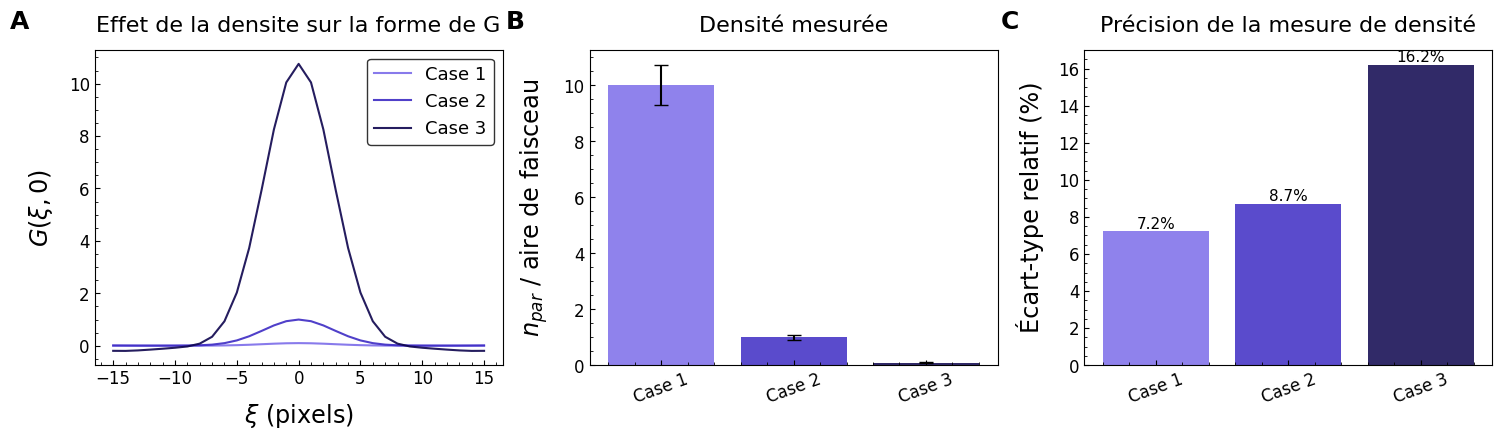

In [3]:
if "density" in dataset:
    res = analyze_category(dataset["density"], pixel_size_um=PIXEL_SIZE_UM_DEFAULT,
                            fit_half_width=FIT_HALF_WIDTH, min_overlap_frac=MIN_OVERLAP_FRAC)
    for case, r in res.items():
        plot_case_overview(r, f"Densite - {case}",
                            savepath=OUTPUT_DIR / f"01_density_overview_{case.replace(' ', '_')}.png")

    fig = plot_density_effect(res, nominal=NOMINAL_DENSITIES or None,
                            savepath=OUTPUT_DIR / "01_density_effect_summary.png")
    buf = io.BytesIO()
    fig.savefig(buf, format="png", bbox_inches="tight", dpi=100)
    buf.seek(0)
    display(Image(data=buf.getvalue()))
    plt.close(fig)

    df = summary_table(res, nominal=NOMINAL_DENSITIES or None)
    df.to_csv(OUTPUT_DIR / "01_density_summary.csv", index=False)
    all_summaries["density"] = df

<!-- À partir des images fournies, étudiez l’effet des différents paramètres suivants sur la fonction 
d’autocorrélation spatiale et sur la précision de l’estimation de la densité de particules : 
• La densité des particules (0.1 to 10 émetteurs / surface effective du laser (pi*wxy2)). -->

$\textbf{A)}$ L'effet de la densité sur la forme de la fonction de corrélation est étudiée. La spectroscopie de corrélation d'image mesure l'amplitude des fluctuations relatives de fluorescence $\delta I / \langle I \rangle$ autour de l'intensité moyenne. Pour des particules indépendantes, l'amplitude de la fonction d'autocorrélation au lag zéro $g(0,0)$ est égale à l'inverse du nombre moyen d'émetteurs $\langle N \rangle$ présents dans la surface effective du laser ($\text{Beam Area} = \pi \cdot \omega_{xy}^2$). Ainsi, une plus grande densité engendre une valeur $g(0,0)$ plus faible. En effet, il est observé que, pour le cas 1, présentant une densité théorique $\langle N \rangle_{\text{théo}} = 10,0$, $g(0,0) = 0,0998$. Le cas 2 présentant une densité théorique $\langle N \rangle_{\text{théo}} = 1,0$, $g(0,0) = 0,9938$. Le cas 3 présentant une densité théorique $\langle N \rangle_{\text{théo}} = 0,1$, $g(0,0) = 10,7$. Lorsque la densité augmente de $0,1$ à $10$ particules/BA, l'amplitude $g(0,0)$ diminue de deux ordres de grandeur (passant de $\sim 10$ à $\sim 0,1$). Une image très dense apparaît visuellement plus lisse et homogène, ce qui réduit la variance spatiale relative.

Il est également observé que la largeur spatiale de la Gaussienne d'autocorrélation (le paramètre $w_0$) reste constante. La largeur dépend uniquement des propriétés optiques du microscope (la tache de diffraction PSF) et non de la quantité de fluorophores observés.

$\textbf{B)}$ Les densités sont mesurées à partir des $g(0,0)$ obtenus. Pour le cas 1, $N \rangle_{\text{estimé}} = 10,0 \pm 0,7$, pour le cas 2 $N \rangle_{\text{estimé}} = 1,01 \pm 0,09$ et pour le cas 3, $N \rangle_{\text{estimé}} = 0,09 \pm 0,02$. L'estimation de la densité est juste et non biaisée sur 3 ordres de grandeur.

$\textbf{C)}$ Une analyse de la précision sur les mesures de densité est effectuée afin de déterminer la tendance. Il est possible d'observer qu'à faible densité ($\langle N \rangle = 0,1$), l'amplitude de fluctuation est forte ($g_0 \approx 10$), mais le nombre restreint d'émetteurs dans l'image augmente l'incertitude relative de mesure d'une image à l'autre. À forte densité ($\langle N \rangle = 10,0$), l'échantillonnage spatial est plus représentatif, stabilisant l'incertitude relative de l'estimation ($\sim 7,2\,\%$).


##### A.2) La durée de la simulation

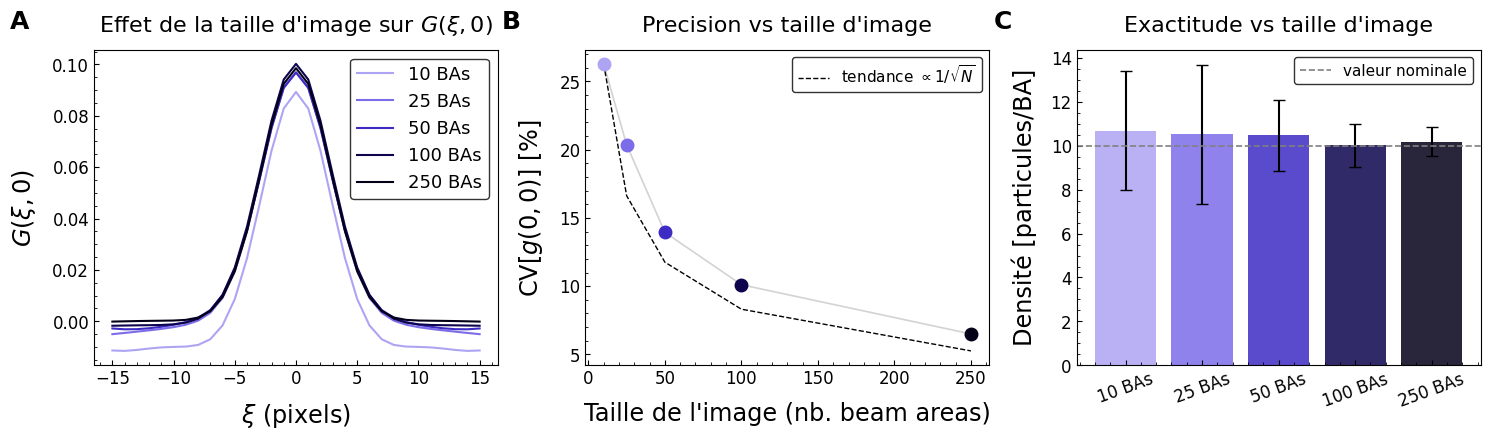

In [4]:
size_key = "image size" if "image size" in dataset else "imagesize"
if size_key in dataset:
    res = analyze_category(dataset[size_key], pixel_size_um=PIXEL_SIZE_UM_DEFAULT,
                            fit_half_width=FIT_HALF_WIDTH, min_overlap_frac=MIN_OVERLAP_FRAC)
    for case, r in res.items():
        hw = min(FIT_HALF_WIDTH, r["Gavg"].shape[0] // 2 - 1)
        plot_case_overview(r, f"Taille d'image - {case}",
                            savepath=OUTPUT_DIR / f"02_imagesize_overview_{case.replace(' ', '_')}.png",
                            half_width_display=hw)
    fig = plot_imagesize_effect(res, nominal_n_per_BA=DEFAULT_DENSITY_PER_BA or None,
                            savepath=OUTPUT_DIR / "02_imagesize_effect_summary.png")

    buf = io.BytesIO()
    fig.savefig(buf, format="png", bbox_inches="tight", dpi=100)
    buf.seek(0)
    display(Image(data=buf.getvalue()))
    plt.close(fig)

    df = summary_table(res)
    df.to_csv(OUTPUT_DIR / "02_imagesize_summary.csv", index=False)
    all_summaries["image_size"] = df

<!-- À partir des images fournies, étudiez l’effet des différents paramètres suivants sur la fonction 
d’autocorrélation spatiale et sur la précision de l’estimation de la densité de particules : 
• La durée de la simulation. Montrez comment la taille de l’image influence la précision. -->

1. Équivalence entre durée de simulation, taille d'image et nombre de Beam Areas (BA)

En ICS spatiale, la durée de la simulation définit la surface de la région générée. Cette taille est mesurée en multiples de la surface du faisceau laser ($\text{Beam Area} = \pi \cdot \omega_{xy}^2$). L'ICS extrait ses paramètres en réalisant une moyenne spatiale des fluctuations d'intensité sur l'ensemble des pixels de l'image. Analyser une image plus grande revient à augmenter le nombre d'échantillons spatiaux indépendants (le nombre de Beam Areas) observés simultanément.

2. Invariance de la justesse (Valeur moyenne de la densité)

La valeur théorique attendue pour la densité est de 10 particules / BA (soit $g(0,0) = 0,10$).
La taille de la fenêtre d'analyse ne doit pas introduire de biais sur la valeur moyenne.

10 BAs : $\text{Mean } g(0,0) = 0{,}1001 \implies \langle N \rangle_{\text{estimé}} = 10{,}66$
25 BAs : $\text{Mean } g(0,0) = 0{,}0998 \implies \langle N \rangle_{\text{estimé}} = 10{,}62$
50 BAs : $\text{Mean } g(0,0) = 0{,}0972 \implies \langle N \rangle_{\text{estimé}} = 10{,}53$
100 BAs : $\text{Mean } g(0,0) = 0{,}1001 \implies \langle N \rangle_{\text{estimé}} = 10{,}09$
250 BAs : $\text{Mean } g(0,0) = 0{,}0984 \implies \langle N \rangle_{\text{estimé}} = 10{,}20$

Quelle que soit la taille de l'image (de 10 à 250 BAs), la densité moyenne estimée reste juste et stable autour de la valeur vraie (10 particules/BA). La taille de l'image ne modifie donc pas la valeur centrale.

3. Impact majeur sur la précision (Loi en $1/\sqrt{\text{Surface}}$)

Le paramètre critique influencé par la taille de l'image est la précision statistique (l'incertitude de mesure). Selon le théorème central limite, la variance d'estimation des fluctuations diminue de manière inversement proportionnelle à la surface d'analyse : 
$$\sigma_{\langle N \rangle} \propto \frac{1}{\sqrt{\text{Nombre de BAs}}}$$

10 BAs : Écart-type $\sigma_{\langle N \rangle} = 2{,}71$ (soit $\sim 25{,}4\,\%$ d'incertitude relative).
25 BAs : $\sigma_{\langle N \rangle} = 3{,}35$.
50 BAs : $\sigma_{\langle N \rangle} = 1{,}68$.
100 BAs : $\sigma_{\langle N \rangle} = 0{,}99$.
250 BAs : $\sigma_{\langle N \rangle} = 0{,}65$ (soit $\sim 6{,}4\,\%$ d'incertitude relative).

Passer de 10 BAs à 250 BAs réduit l'incertitude statistique d'un facteur 4, améliorant considérablement la répétabilité du calcul d'une simulation à l'autre1.4. Effet sur la forme de la fonction d'autocorrélation $G(\xi, \eta)$ et compromis biologique.

Sur de petites fenêtres (ex. 10 BAs ou $16 \times 16$ pixels), la fonction d'autocorrélation souffre de bruits statistiques aux grands lags spatiaux (pics aléatoires de chevauchement). Cela peut compliquer l'ajustement du décalage asymptotique $g_\infty$. À l'inverse, sur une grande surface (250 BAs), le fond s'égalise et la décroissance gaussienne vers zéro devient parfaitement lisse.

En microscopie réelle, bien qu'une très grande image améliore la précision, l'analyseur est limité par la géométrie de la cellule2. Il faut choisir la plus grande région homogène possible en s'assurant d'être entièrement "sur la cellule" (on cell), car les bords cellulaires ou les hétérogénéités introduiraient des artefacts majeurs dans la corrélation29.

##### A.3) Discutez comment le bruit du détecteur

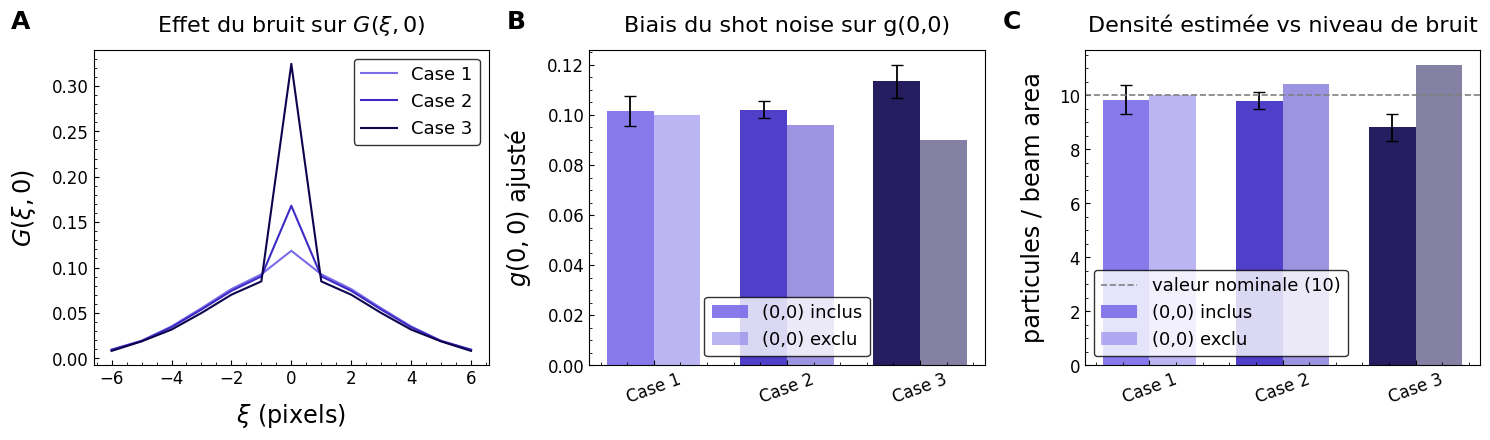

In [5]:
if "noise" in dataset:
    res = analyze_category(dataset["noise"], pixel_size_um=PIXEL_SIZE_UM_DEFAULT,
                            fit_half_width=FIT_HALF_WIDTH, min_overlap_frac=MIN_OVERLAP_FRAC)
    for case, r in res.items():
        plot_case_overview(r, f"Bruit - {case}",
                            savepath=OUTPUT_DIR / f"03_noise_overview_{case.replace(' ', '_')}.png")
    fig = plot_noise_effect(res, savepath=OUTPUT_DIR / "03_noise_effect_summary.png")

    buf = io.BytesIO()
    fig.savefig(buf, format="png", bbox_inches="tight", dpi=100)
    buf.seek(0)
    display(Image(data=buf.getvalue()))
    plt.close(fig)

    df = summary_table(res)
    df.to_csv(OUTPUT_DIR / "03_noise_summary.csv", index=False)
    all_summaries["noise"] = df

##### A.4) La taille du pixel

c:\Users\User\OneDrive\Bureau\Université\Maitrise\cours\Analyse des signaux\Projets\Projet 3\ICS_analysis\ics_core.py:177: OptimizeWarning: Covariance of the parameters could not be estimated
  popt, pcov = curve_fit(_gaussian2d, xdata, ydata, p0=p0, maxfev=20000)


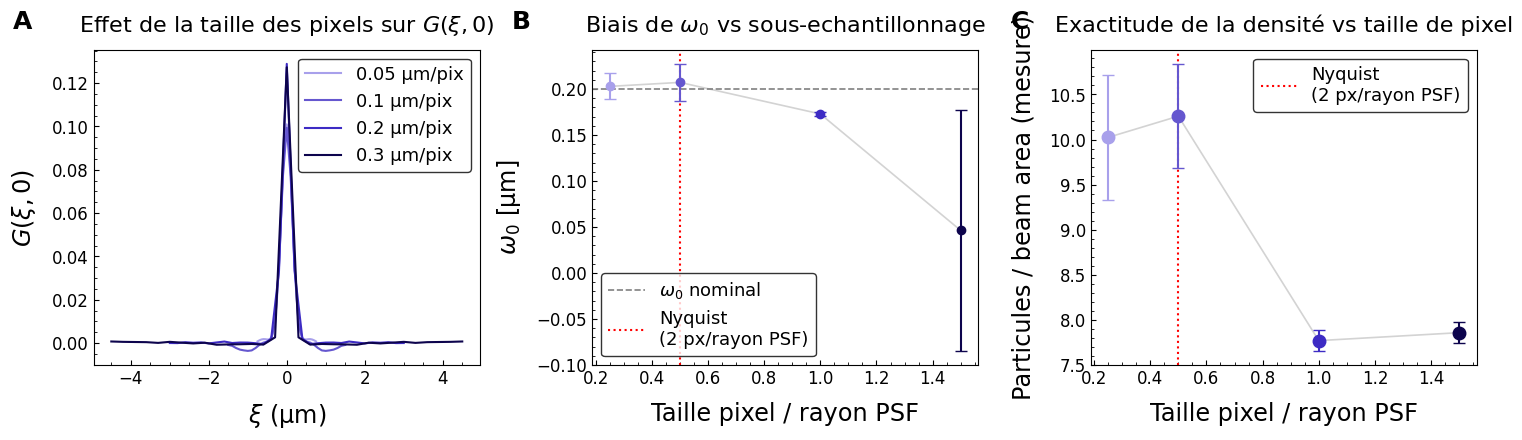

In [6]:
ps_key = "pixel size" if "pixel size" in dataset else "pixelsize"
if ps_key in dataset:
    cases = dataset[ps_key]
    pixel_size_map = {c: pixel_size_from_case_name(c) for c in cases}
    res = analyze_category(cases, pixel_size_um=pixel_size_map,
                            fit_half_width=FIT_HALF_WIDTH, min_overlap_frac=MIN_OVERLAP_FRAC)
    for case, r in res.items():
        hw = min(FIT_HALF_WIDTH, r["Gavg"].shape[0] // 2 - 1)
        plot_case_overview(r, f"Taille de pixel - {case}",
                            savepath=OUTPUT_DIR / f"04_pixelsize_overview_{case.replace(' ', '_')}.png",
                            half_width_display=hw)
    fig = plot_pixelsize_effect(res, nominal_omega_um=PSF_OMEGA_UM,
                            savepath=OUTPUT_DIR / "04_pixelsize_effect_summary.png")

    buf = io.BytesIO()
    fig.savefig(buf, format="png", bbox_inches="tight", dpi=100)
    buf.seek(0)
    display(Image(data=buf.getvalue()))
    plt.close(fig)

    df = summary_table(res)
    df.to_csv(OUTPUT_DIR / "04_pixelsize_summary.csv", index=False)
    all_summaries["pixel_size"] = df


<!-- À partir des images fournies, étudiez l’effet des différents paramètres suivants sur la fonction 
d’autocorrélation spatiale et sur la précision de l’estimation de la densité de particules : 
• La taille du pixel. Montrez ce qui se passe sur la fonction de corrélation spatiale si la taille 
du pixel est trop grande par rapport au rayon de la PSF.  -->


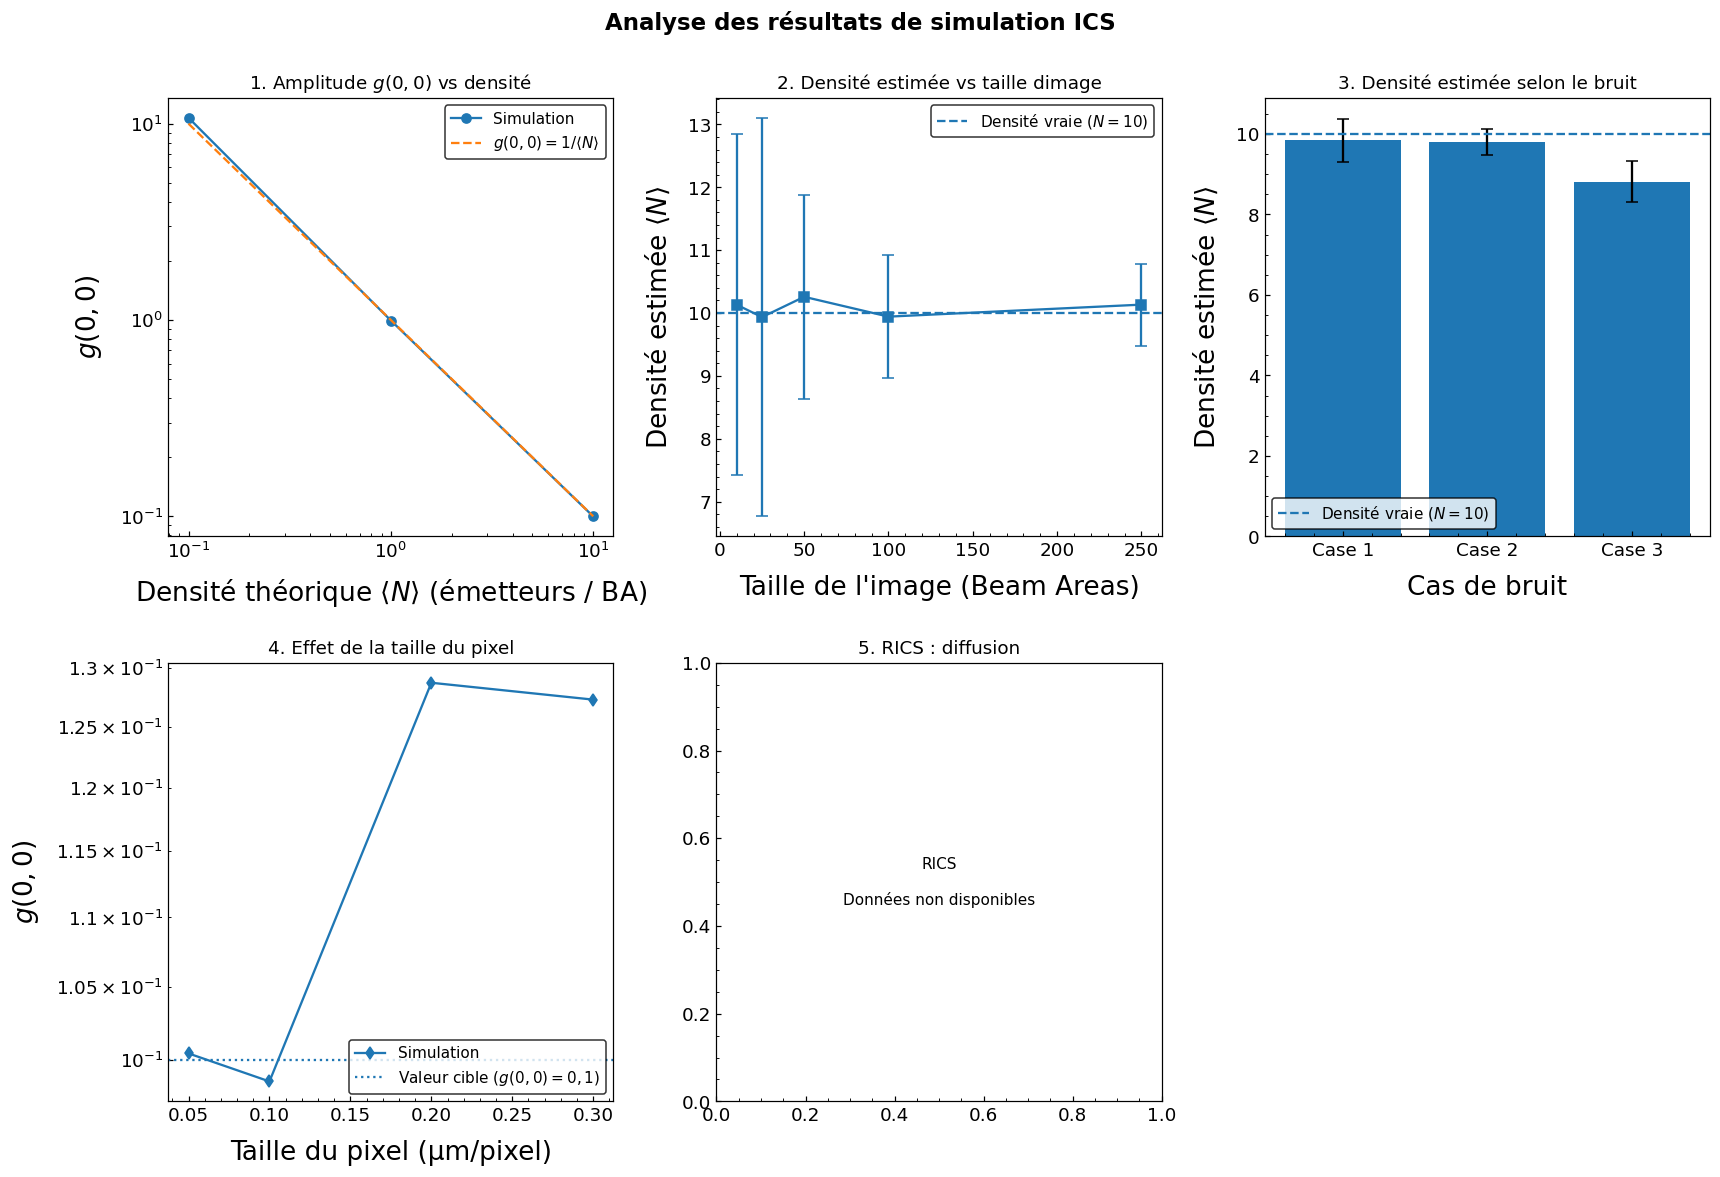

In [7]:
%matplotlib inline
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os

plt.close('all')

# 2. Chargement des fichiers
df_den = pd.read_csv(r'C:\Users\User\OneDrive\Bureau\Université\Maitrise\cours\Analyse des signaux\Projets\Projet 3\ICS_analysis\resultats_ICS\01_density_summary.csv')
df_sz = pd.read_csv(r'C:\Users\User\OneDrive\Bureau\Université\Maitrise\cours\Analyse des signaux\Projets\Projet 3\ICS_analysis\resultats_ICS\02_imagesize_summary.csv')
df_ns = pd.read_csv(r'C:\Users\User\OneDrive\Bureau\Université\Maitrise\cours\Analyse des signaux\Projets\Projet 3\ICS_analysis\resultats_ICS\03_noise_summary.csv')
df_px = pd.read_csv(r'C:\Users\User\OneDrive\Bureau\Université\Maitrise\cours\Analyse des signaux\Projets\Projet 3\ICS_analysis\resultats_ICS\04_pixelsize_summary.csv')

# 3. Préparation des données
# A. DENSITÉ
density_map = {'Case 1': 10.0, 'Case 2': 1.0, 'Case 3': 0.1}
df_den['Expected_N'] = df_den['cas'].map(density_map)
df_den = df_den.sort_values('Expected_N')

# B. TAILLE D'IMAGE
# Extrait le premier nombre de "23x23", "71x71", etc.
df_sz['Image_Size'] = (df_sz['taille_image'].str.extract(r'(\d+)').astype(float))

# Extrait le nombre de BAs de "10 BAs", "25 BAs", etc.
df_sz['BA'] = (df_sz['cas'].str.extract(r'([0-9.]+)').astype(float))
df_sz = df_sz.sort_values('BA')

# C. BRUIT
# Rien à extraire :
# les valeurs de n_par_BA sont déjà disponibles


# D. TAILLE DU PIXEL
df_px['Pixel_Size'] = df_px['pixel_size_um']
df_px = df_px.sort_values('Pixel_Size')

# 4. Graphiques
fig, axes = plt.subplots(2, 3, figsize=(16, 11))
fig.suptitle('Analyse des résultats de simulation ICS', fontsize=15, fontweight='bold')

# GRAPHIQUE 1 : g(0,0) vs densité
axes[0, 0].plot(df_den['Expected_N'], df_den['g0'], 'o-', label='Simulation')

# Relation théorique
densite_theorique = np.logspace(-1, 1, 50)

axes[0, 0].plot(densite_theorique, 1.0 / densite_theorique, '--', label=r'$g(0,0)=1/\langle N\rangle$')
axes[0, 0].set_xscale('log')
axes[0, 0].set_yscale('log')
axes[0, 0].set_title(r'1. Amplitude $g(0,0)$ vs densité')
axes[0, 0].set_xlabel(r'Densité théorique $\langle N\rangle$ (émetteurs / BA)')
axes[0, 0].set_ylabel(r'$g(0,0)$')
axes[0, 0].legend()

# GRAPHIQUE 2 : précision vs taille d'image
axes[0, 1].errorbar(df_sz['BA'], df_sz['n_par_BA'], yerr=df_sz['n_par_BA_std_repet'], fmt='s-', capsize=4)

# Valeur vraie
axes[0, 1].axhline(10.0, linestyle='--', label=r'Densité vraie ($N=10$)')
axes[0, 1].set_title(r'2. Densité estimée vs taille d''image')
axes[0, 1].set_xlabel('Taille de l\'image (Beam Areas)')
axes[0, 1].set_ylabel(r'Densité estimée $\langle N\rangle$')
axes[0, 1].legend()

# GRAPHIQUE 3 : effet du bruit
axes[0, 2].bar(df_ns['cas'], df_ns['n_par_BA'], yerr=df_ns['n_par_BA_std_repet'], capsize=4)
axes[0, 2].axhline(10.0, linestyle='--', label=r'Densité vraie ($N=10$)')
axes[0, 2].set_title('3. Densité estimée selon le bruit')
axes[0, 2].set_xlabel('Cas de bruit')
axes[0, 2].set_ylabel(r'Densité estimée $\langle N\rangle$')
axes[0, 2].legend()

# GRAPHIQUE 4 : taille du pixel
axes[1, 0].plot(df_px['Pixel_Size'], df_px['g0'], 'd-', label='Simulation')
axes[1, 0].axhline(0.10, linestyle=':', label=r'Valeur cible ($g(0,0)=0,1$)')
axes[1, 0].set_yscale('log')
axes[1, 0].set_title('4. Effet de la taille du pixel')
axes[1, 0].set_xlabel('Taille du pixel (µm/pixel)')
axes[1, 0].set_ylabel(r'$g(0,0)$')
axes[1, 0].legend()

# GRAPHIQUE 5 : RICS — réservé pour le 5e fichier
axes[1, 1].text(0.5, 0.5, 'RICS\n\nDonnées non disponibles', ha='center', va='center', transform=axes[1, 1].transAxes)
axes[1, 1].set_title('5. RICS : diffusion')
axes[1, 2].axis('off')

plt.tight_layout(pad=2.0)
plt.show()